### Load dataset

In [1]:
import os
import sys
import math
from tqdm import tqdm
from pathlib import Path
from typing import Any, overload
from collections import defaultdict

import torch
import wandb
import numpy as np
from torch import nn, Tensor
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Optimizer, AdamW
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import LRScheduler, LambdaLR

from src.models import MAE_ViT
from src import configs as cfg
from src import models, plotting
from src.utils import setup_seed
from src import dataset, metrics, plotting

/root/repos/raidium_challenge/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
path = "checkpoints/unet/unet_epoch_599.pt"

In [3]:
chkpt = torch.load(path, weights_only=False)
train_cfg = chkpt["train_cfg"]
if "mask_rec_loss_weight" in train_cfg:
    del train_cfg["mask_rec_loss_weight"]
train_cfg = cfg.TrainingConfig(**train_cfg)
model_cfg = cfg.ModelConfig(**chkpt["model_cfg"])

if model_cfg.architecutre == "vit":
    model = MAE_ViT.from_config(model_cfg, True)
elif model_cfg.architecutre == "unet":
    model = models.mk_unet(model_cfg)
model.load_state_dict(chkpt["model"])

<All keys matched successfully>

In [4]:
loaders = dataset.mk_data_loaders_for_segmentation(train_cfg)

In [5]:
chkpt.keys()

dict_keys(['model', 'model_cfg', 'train_cfg', 'optimizer', 'lr_scheduler', 'epoch', 'training_samples_seen'])

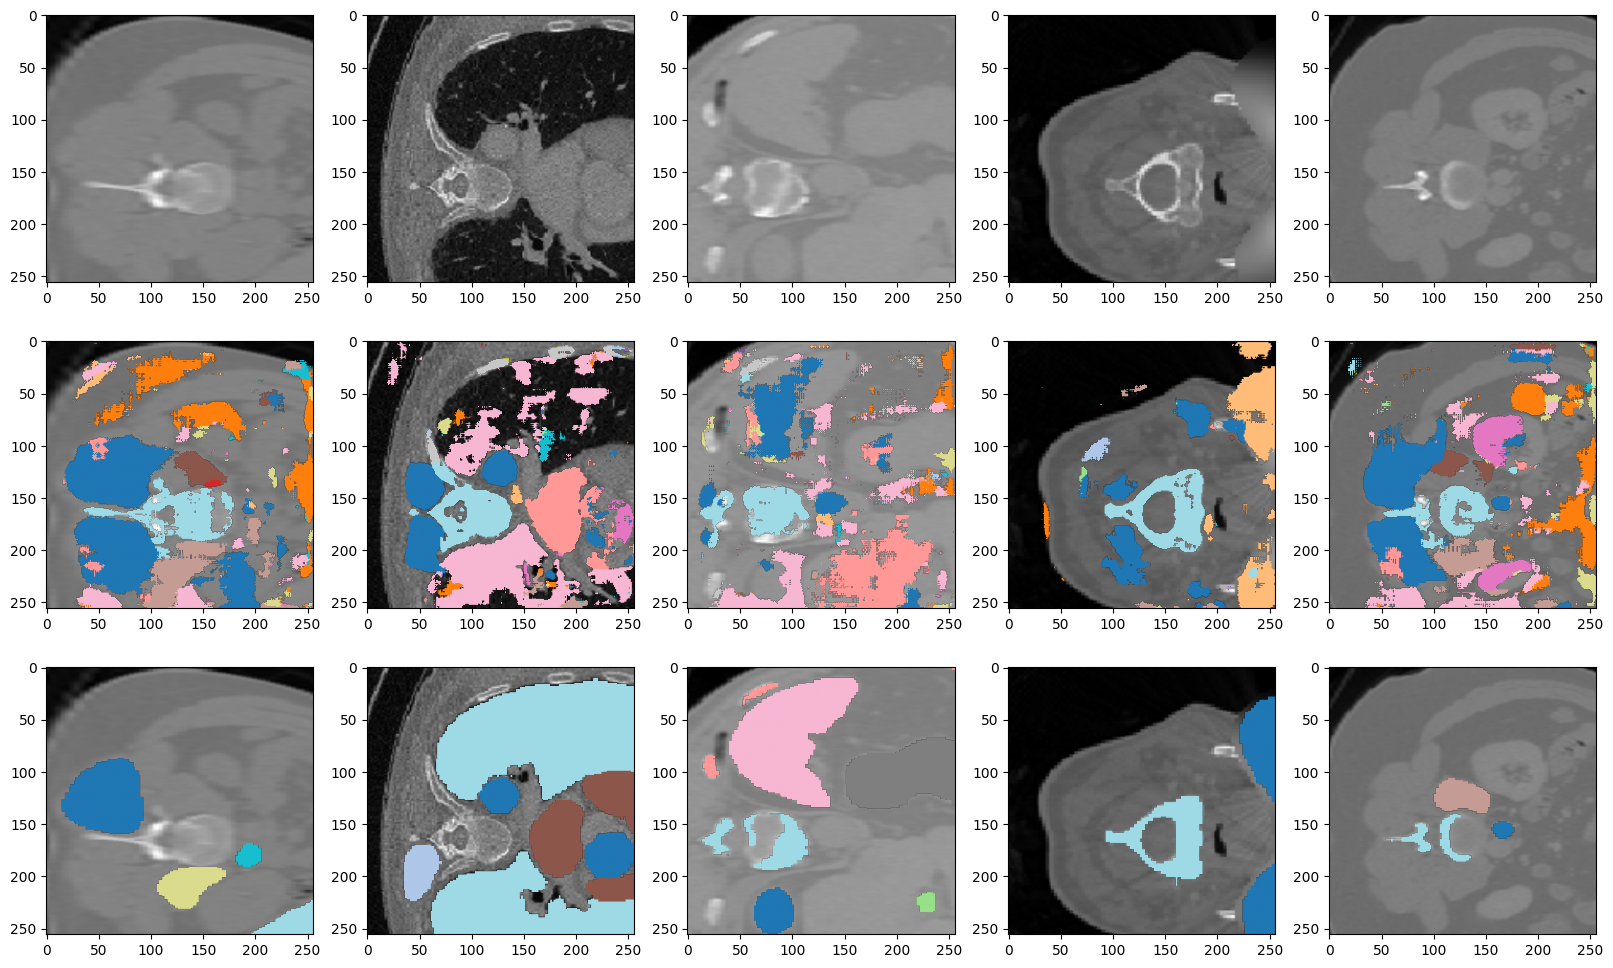

In [16]:
x, y_true = next(iter(loaders["train"]))
from torchvision.transforms import v2
crop_trans = v2.RandomApply(
    torch.nn.ModuleList([
        v2.RandomResizedCrop(256, (0.3, 0.5)),
        ]
    )
)
trans = v2.Compose([v2.RandomResizedCrop(256, (0.3, 1)), chkpt["train_cfg"]["transform"]])
plotting.plt_seg_pred(model, {"x": x, "y_true": y_true}, crop_trans)

In [7]:
import plotly.express as px
from src import plotting

def plt_recon_imgs(model: nn.Module, loader: DataLoader):
    x, y_true = next(iter(loader))
    x = dataset.preprocess_imgs(x)[:plotting.MAX_N_SAMPLES_TO_PLOT]
    x_hat, mask = model(x, 0.65)
    x_hat_img = x_hat[:, :1]
    mask = mask[:, :1]
    x_hat_img = x_hat_img * mask + x * (1 - mask)
    img = torch.cat(
        [
            x * (1 - mask),
            x_hat_img,
            x,
        ],
        dim=0,
    )
    # img = img * dataset.STD + dataset.MEAN 
    np_imgs = (
        img
        .detach()
        .cpu()
        .numpy()
        .squeeze()
    )
    fig = px.imshow(
        np_imgs,
        facet_col=0,
        facet_col_wrap=plotting.MAX_N_SAMPLES_TO_PLOT,
        color_continuous_scale="rainbow",
    )
    fig.show()

plt_recon_imgs(model, loaders["train"])

TypeError: UnetWrapper.forward() takes 2 positional arguments but 3 were given

In [ ]:
print("train")
plotting.plt_model_preds(model, loaders["train"], plt_recon=False, mask_ratio=0, transform=chkpt["train_cfg"]["transform"])
print("valid")
plotting.plt_model_preds(model, loaders["valid"], plt_recon=False, mask_ratio=0)

### Make submission

In [ ]:
from tqdm import tqdm

import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

@torch.no_grad
def mk_submission(model: nn.Module, x_test: Tensor, batch_size: int=128):
    test_loader = DataLoader(x_test, batch_size=batch_size, shuffle=False)
    predictions = []

    for image in tqdm(test_loader) :
        image = image.to(device=device)
        y_pred_logits = model(image)
        pred = torch.argmax(y_pred_logits, dim=1)
        print(pred.shape)
        predictions.append(pred.cpu().numpy())

    predictions = np.concat(predictions)
    print("n unique values:", len(np.unique(predictions)))
    df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T
    df.index = [f"Pixel {i}" for i in df.index]
    df.columns = [f"{col}.png" for col in df.columns]
    df.to_csv("submission.csv")

mk_submission(model, x_test)